# Iris Project - KMeans and Hierarchical

![Iris Image](iris.png)

### Objective

The objective of this project is to apply unsupervised machine learning techniques, specifically KMeans and Hierarchical clustering, to the Iris dataset in order to identify natural groupings in the data based on feature similarity. The project aims to understand how clustering algorithms work and to visualize the structure of the data without using predefined labels.

### Dataset
We are using the famous Iris dataset available in sklearn.

In [3]:
# Import required libraries

import pandas as pd   # for data handling
import numpy as np     # for numerical operation
import matplotlib.pyplot as plt    # for plottting
import seaborn as sns     # for visualisation
from sklearn.preprocessing import StandardScaler   # for Feature Scaling
from sklearn.cluster import KMeans      # Algorithm
import scipy.cluster.hierarchy as sch    # Dendrogram
from sklearn.cluster import AgglomerativeClustering   #Algorithm

In [16]:
# Load the dataset
df = sns.load_dataset('iris')

In [15]:
#First 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [17]:
# Last 5 rows
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [12]:
# Shape of the dataset
df.shape

(150, 5)

In [13]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [14]:
# Statistical information
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [21]:
# Check missing values
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [18]:
# Check duplicate values
df.duplicated().sum()

np.int64(1)

In [20]:
# Drop duplicate values
df = df.drop_duplicates()

In [22]:
df.shape

(149, 5)

In [24]:
# Remove target column because Clustering is an unsupervised learning technique
df = df.drop('species',axis = 1)

In [25]:
df.shape

(149, 4)

In [26]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## KMeans Clustering

### How KMeans clustering works:
    
* KMeans divides the dataset into a fixed number of clusters (K)
* It randomly initializes cluster centers (centroids)
* Each data point is assigned to the nearest centroid based on distance
* Centroids are updated by calculating the mean of assigned points
* This process repeats until cluster assignments stop changing

In [28]:
# Calculate WCSS for different numbers of clusters

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

C:\Users\shifa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\shifa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\shifa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\shifa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

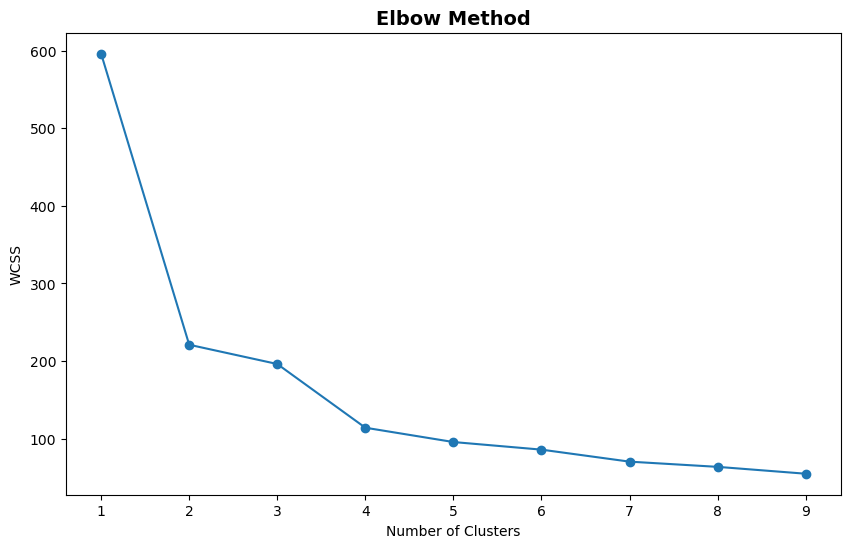

In [30]:
# Plot Elbow Method
plt.figure(figsize=(10,6))
plt.plot(range(1, 10), wcss, marker='o')
plt.title("Elbow Method",fontsize = 14,fontweight = "bold")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [64]:
# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42,n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

C:\Users\shifa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


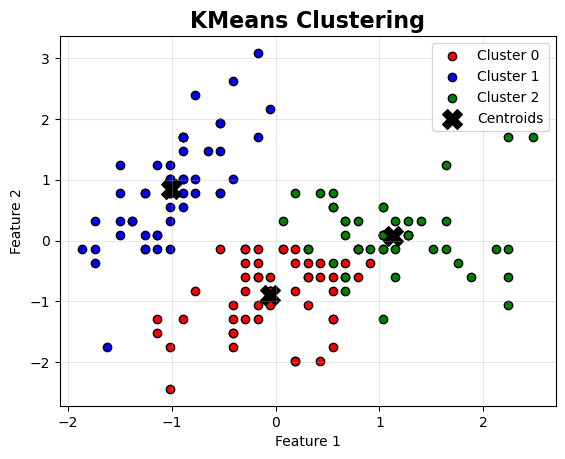

In [69]:
# Visualize Clusters

colors = ['red', 'blue', 'green']

for i in range(3):
    plt.scatter(X_scaled[kmeans_labels == i, 0],
                X_scaled[kmeans_labels == i, 1],
                color=colors[i],
                label=f'Cluster {i}',
                edgecolor = "black")
# Plot Centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, color='black', marker='X', label='Centroids')

plt.legend()
plt.title("KMeans Clustering",fontsize = 16,fontweight = "bold")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.3)
plt.show()

### Why KMeans is suitable for the Iris dataset
* The dataset has clear and well-separated groups
* The number of clusters is known (3 species)
* Features are numerical, which works well with distance-based methods
* It is simple, fast, and effective for small datasets like Iris

### Insights

* The data is grouped into three distinct clusters
* One cluster is clearly separated from the others
* The remaining two clusters show slight overlap
* Clustering pattern is consistent with natural groupings in the dataset
* Indicates that KMeans works effectively for this dataset

## Hierarchical Clustering - Dendrogram

### How Hierarchical clustering works
* It builds clusters step by step using a bottom-up approach
* Each data point starts as its own cluster
* Closest clusters are merged based on distance
* This process continues until all points form a single cluster
* The result is shown as a tree-like structure called a dendrogram

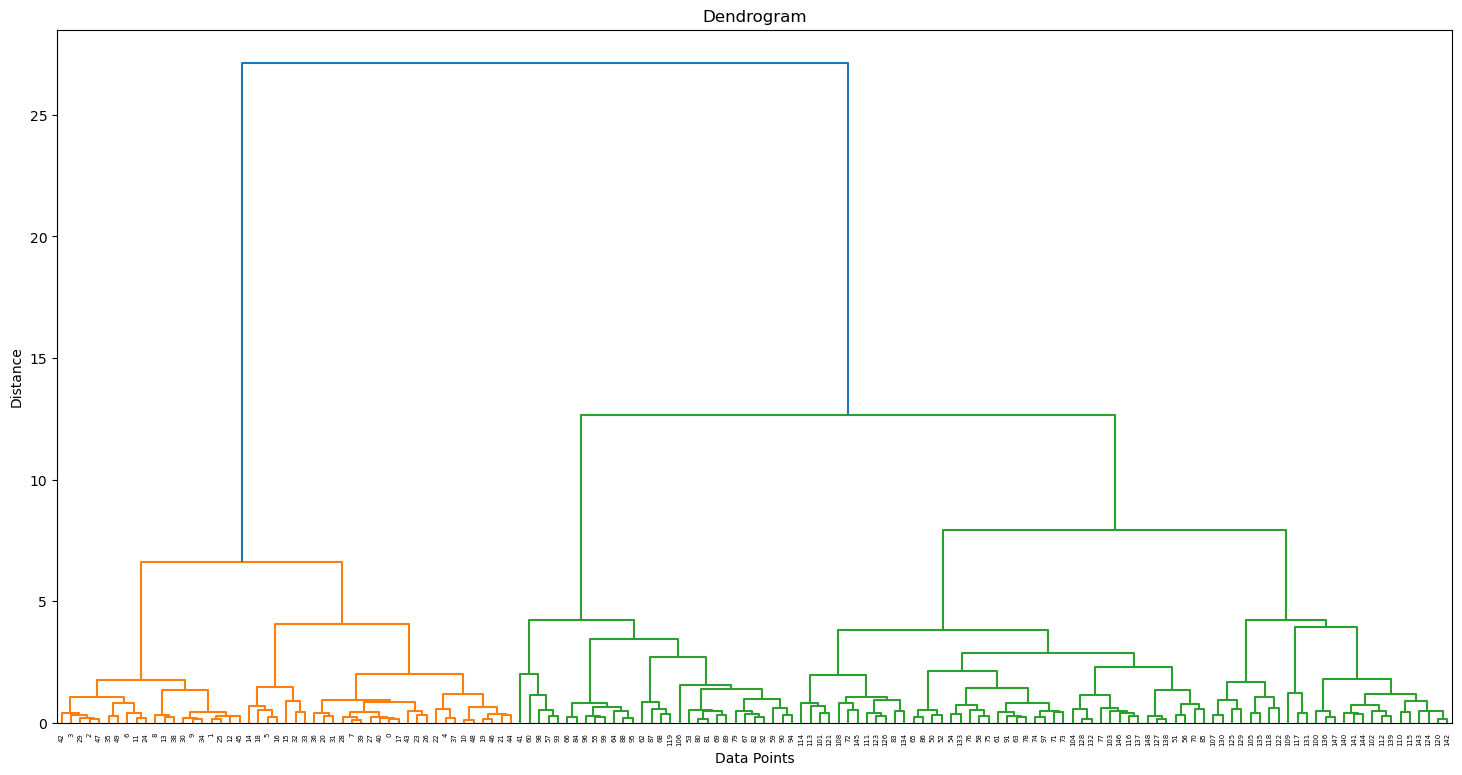

In [43]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(18,9))
sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

### Insights

* The dendrogram shows how data points are merged step by step
* Large vertical distances indicate clear separation between clusters
* A clear cut can be made at three clusters
* One cluster forms early, showing strong similarity within that group
* The remaining data points merge at higher distances, indicating less separation

In [44]:
# Apply Hierarchical Clustering

from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X_scaled)

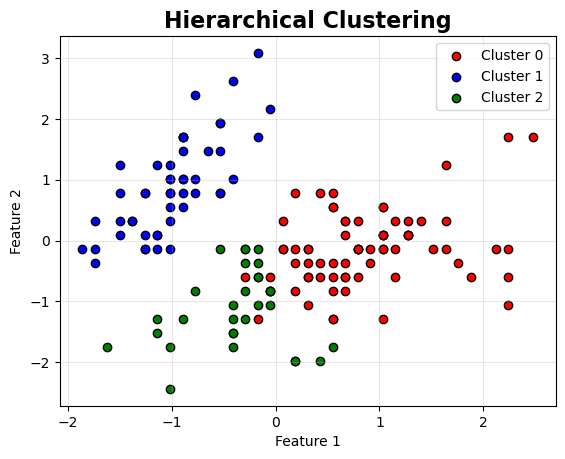

In [61]:
# Visualize clusters

colors = ['red', 'blue', 'green']

for i in range(3):
    plt.scatter(X_scaled[hc_labels == i, 0],
                X_scaled[hc_labels == i, 1],
                color=colors[i],
                label=f'Cluster {i}',
                edgecolor = "black")

plt.legend()
plt.title("Hierarchical Clustering",fontsize = 16,fontweight = "bold")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.3)
plt.show()

### Why Hierarchical clustering is suitable for the Iris dataset
* It does not require specifying the number of clusters initially
* Dendrogram helps visualize cluster relationships clearly
* Works well for small datasets like Iris
* Can reveal natural grouping structure in the data

### Insights

* Data points are grouped into three clusters similar to KMeans
* One cluster is clearly distinct from the rest
* Some overlap is observed between two clusters
* Cluster formation is slightly less compact compared to KMeans
* Overall clustering pattern is similar to KMeans
* The method reveals relationships between data points through hierarchy

## Conclusion

This project demonstrates the application of clustering techniques on the Iris dataset using KMeans and Hierarchical clustering. The dataset was preprocessed by removing the species column and scaling the features to ensure accurate clustering.

KMeans clustering was applied by selecting an appropriate number of clusters, and the results showed that the data could be grouped into distinct clusters based on feature similarity. The visualization of clusters indicates that the algorithm was able to identify meaningful patterns in the dataset.

Hierarchical clustering was implemented using a dendrogram to determine the number of clusters. The dendrogram clearly showed the grouping structure of the data, and the final clustering also formed distinct groups.

Overall, both clustering techniques successfully identified the natural grouping present in the Iris dataset, demonstrating their effectiveness in unsupervised learning tasks.